# AuraFitness Dataset Exploration

This notebook explores real datasets only.

Goals:

1. Load real datasets from `ai/datasets/raw/`
2. Check rows and columns
3. Analyze missing values
4. Create charts
5. Identify useful columns
6. Decide which datasets are suitable for AuraFitness MVP

Rule:

No fake or sample dataset is allowed for AI training or evaluation.

## Imports and Paths

This cell imports the libraries used for dataset loading, analysis, and charts. It also detects the `ai/` folder whether the notebook is opened from `ai/` or `ai/notebooks/`, then creates the figures directory if needed.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

# If notebook opens from ai/notebooks, move root to ai/
if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

RAW_DATA_DIR = AI_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = AI_ROOT / "datasets" / "processed"
FIGURES_DIR = AI_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Figures directory:", FIGURES_DIR)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai
Raw data directory: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\datasets\raw
Figures directory: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures


## Find Real Dataset Files

This cell searches `ai/datasets/raw/` for supported real data files. If no CSV, Excel, or JSON files exist, it stops the notebook so we do not accidentally analyze fake or missing data.

In [2]:
supported_extensions = [".csv", ".xlsx", ".xls", ".json"]

dataset_files = []

for extension in supported_extensions:
    dataset_files.extend(RAW_DATA_DIR.rglob(f"*{extension}"))

if not dataset_files:
    raise FileNotFoundError(
        "No real dataset files found.\n"
        "Download real datasets into ai/datasets/raw/ before continuing."
    )

print("Found dataset files:")
for file in dataset_files:
    print("-", file.relative_to(AI_ROOT))

Found dataset files:
- datasets\raw\fitness_exercises\exercises.csv
- datasets\raw\gym_members\gym_members_exercise_tracking.csv
- datasets\raw\gym_exercises\Gym Exercises Dataset.xlsx


## Dataset Loader

This cell defines one loader function for CSV, Excel, and JSON files. It then loads every discovered real dataset into a dictionary with the original path and a pandas DataFrame.

In [3]:
def load_dataset(file_path: Path):
    """
    Load a real dataset file.

    Supported:
    - CSV
    - Excel
    - JSON
    """
    suffix = file_path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path)

    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    if suffix == ".json":
        return pd.read_json(file_path)

    raise ValueError(f"Unsupported file format: {suffix}")


datasets = {}

for file_path in dataset_files:
    try:
        df = load_dataset(file_path)
        datasets[file_path.stem] = {
            "path": file_path,
            "data": df
        }
        print(f"Loaded: {file_path.name} -> shape {df.shape}")
    except Exception as error:
        print(f"Could not load {file_path.name}: {error}")

Loaded: exercises.csv -> shape (1324, 23)
Loaded: gym_members_exercise_tracking.csv -> shape (973, 15)
Loaded: Gym Exercises Dataset.xlsx -> shape (471, 10)


## Dataset Overview Table

This cell creates a compact summary for each loaded dataset: file path, row count, column count, missing value count, and duplicate row count.

In [4]:
overview_rows = []

for name, item in datasets.items():
    df = item["data"]
    overview_rows.append({
        "dataset_name": name,
        "file_path": str(item["path"].relative_to(AI_ROOT)),
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,dataset_name,file_path,rows,columns,missing_values,duplicate_rows
0,exercises,datasets\raw\fitness_exercises\exercises.csv,1324,23,12217,0
1,gym_members_exercise_tracking,datasets\raw\gym_members\gym_members_exercise_...,973,15,0,0
2,Gym Exercises Dataset,datasets\raw\gym_exercises\Gym Exercises Datas...,471,10,490,0


## Dataset Size Chart

This cell visualizes row counts so we can quickly compare dataset size and spot very small or unusually large sources.

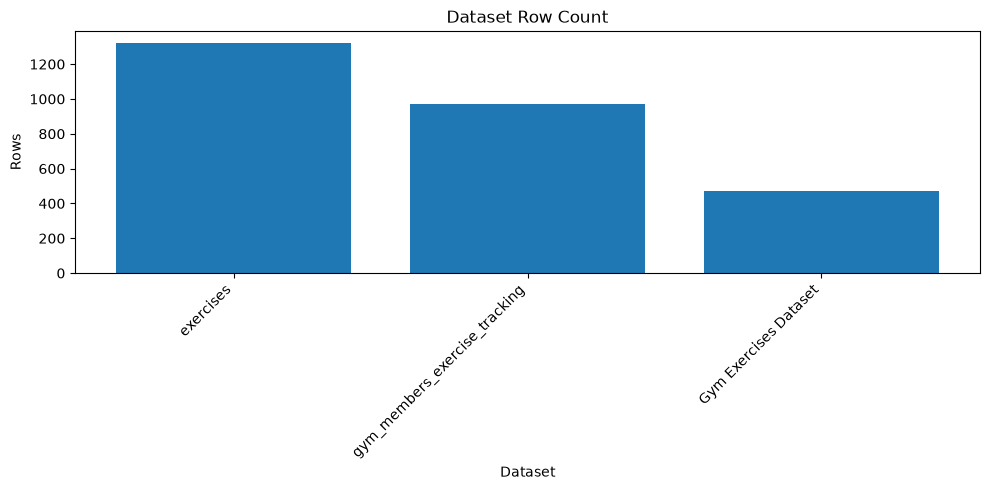

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\dataset_row_count.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(overview_df["dataset_name"], overview_df["rows"])
plt.title("Dataset Row Count")
plt.xlabel("Dataset")
plt.ylabel("Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "dataset_row_count.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved chart:", output_path)

## Missing Values Chart

This cell compares total missing values by dataset. Datasets with many missing values may need more cleaning before MVP usage.

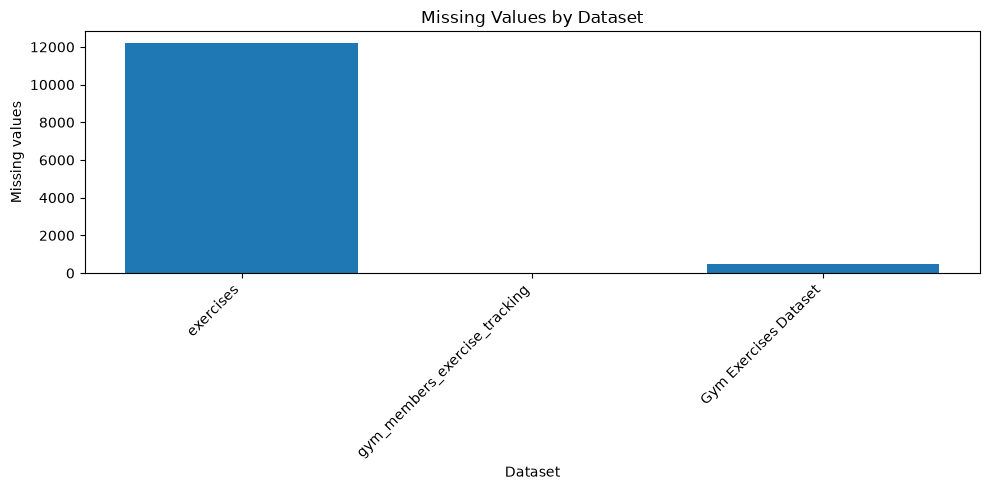

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\missing_values_by_dataset.png


In [6]:
plt.figure(figsize=(10, 5))
plt.bar(overview_df["dataset_name"], overview_df["missing_values"])
plt.title("Missing Values by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Missing values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "missing_values_by_dataset.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved chart:", output_path)

## Inspect Columns

This cell prints each dataset name, path, shape, column list, and first rows. Use this output to decide which columns are useful for recommendations, calorie estimation, and cleanup.

In [7]:
for name, item in datasets.items():
    df = item["data"]
    print("\n" + "=" * 80)
    print("Dataset:", name)
    print("Path:", item["path"].relative_to(AI_ROOT))
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    display(df.head())


Dataset: exercises
Path: datasets\raw\fitness_exercises\exercises.csv
Shape: (1324, 23)
Columns:
['bodyPart', 'equipment', 'gifUrl', 'id', 'name', 'target', 'secondaryMuscles/0', 'secondaryMuscles/1', 'instructions/0', 'instructions/1', 'instructions/2', 'instructions/3', 'instructions/4', 'instructions/5', 'secondaryMuscles/2', 'instructions/6', 'instructions/7', 'secondaryMuscles/3', 'instructions/8', 'secondaryMuscles/4', 'instructions/9', 'secondaryMuscles/5', 'instructions/10']


,bodyPart,equipment,gifUrl,id,name,target,secondaryMuscles/0,secondaryMuscles/1,instructions/0,instructions/1,...,instructions/5,secondaryMuscles/2,instructions/6,instructions/7,secondaryMuscles/3,instructions/8,secondaryMuscles/4,instructions/9,secondaryMuscles/5,instructions/10
0,waist,body weight,https://v2.exercisedb.io/image/MOnK4iG0MEt9h8,1,3/4 sit-up,abs,hip flexors,lower back,Lie flat on your back with your knees bent and...,Place your hands behind your head with your el...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,waist,body weight,https://v2.exercisedb.io/image/PERWLDGUxVbpHS,2,45° side bend,abs,obliques,NaN,Stand with your feet shoulder-width apart and ...,Keeping your back straight and your core engag...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,waist,body weight,https://v2.exercisedb.io/image/PLr4yo3j-f1amp,3,air bike,abs,hip flexors,NaN,Lie flat on your back with your hands placed b...,Lift your legs off the ground and bend your kn...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,upper legs,body weight,https://v2.exercisedb.io/image/XPQwM7HECjgNFE,1512,all fours squad stretch,quads,hamstrings,glutes,Start on all fours with your hands directly un...,"Extend one leg straight back, keeping your kne...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,waist,body weight,https://v2.exercisedb.io/image/5nYph4eUGNiEdf,6,alternate heel touchers,abs,obliques,NaN,Lie flat on your back with your knees bent and...,"Extend your arms straight out to the sides, pa...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset: gym_members_exercise_tracking
Path: datasets\raw\gym_members\gym_members_exercise_tracking.csv
Shape: (973, 15)
Columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39



Dataset: Gym Exercises Dataset
Path: datasets\raw\gym_exercises\Gym Exercises Dataset.xlsx
Shape: (471, 10)
Columns:
['Exercise_Name', 'Description_URL', 'Exercise_Image', 'Exercise_Image1', 'muscle_gp_details', 'muscle_gp', 'equipment_details', 'Equipment', 'Rating', 'Description']


,Exercise_Name,Description_URL,Exercise_Image,Exercise_Image1,muscle_gp_details,muscle_gp,equipment_details,Equipment,Rating,Description
0,Rickshaw Carry,https://www.bodybuilding.com/exercises/ricksha...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/exercises/muscle/...,Forearms,https://www.bodybuilding.com/exercises/equipme...,Other,9.6,Average
1,Single-Leg Press,https://www.bodybuilding.com/exercises/single-...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Quadriceps,https://www.bodybuilding.com/exercises/equipme...,Machine,9.6,Average
2,Landmine twist,https://www.bodybuilding.com/exercises/landmin...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Abdominals,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average
3,Weighted pull-up,https://www.bodybuilding.com/exercises/weighte...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Lats,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average
4,T-Bar Row with Handle,https://www.bodybuilding.com/exercises/t-bar-r...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/images/2020/octob...,https://www.bodybuilding.com/exercises/muscle/...,Middle Back,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average


## Helper for Finding Useful Columns

This cell searches each dataset's column names for exercise-related and calorie/workout metric keywords. It helps identify candidate fields without manually scanning every column.

In [8]:
def find_columns(df: pd.DataFrame, keywords: list[str]) -> list[str]:
    """
    Find columns that contain any keyword.
    """
    matched_columns = []

    for column in df.columns:
        normalized_column = column.lower().replace("_", " ").replace("-", " ")

        for keyword in keywords:
            if keyword.lower() in normalized_column:
                matched_columns.append(column)
                break

    return matched_columns


exercise_keywords = [
    "exercise", "name", "body", "part", "target", "muscle",
    "equipment", "instruction", "description", "gif"
]

calorie_keywords = [
    "calorie", "duration", "heart", "weight", "height",
    "age", "gender", "workout", "experience", "fat"
]

for name, item in datasets.items():
    df = item["data"]

    print("\n" + "=" * 80)
    print("Dataset:", name)

    print("Possible exercise columns:")
    print(find_columns(df, exercise_keywords))

    print("Possible calorie / workout metric columns:")
    print(find_columns(df, calorie_keywords))


Dataset: exercises
Possible exercise columns:
['bodyPart', 'equipment', 'gifUrl', 'name', 'target', 'secondaryMuscles/0', 'secondaryMuscles/1', 'instructions/0', 'instructions/1', 'instructions/2', 'instructions/3', 'instructions/4', 'instructions/5', 'secondaryMuscles/2', 'instructions/6', 'instructions/7', 'secondaryMuscles/3', 'instructions/8', 'secondaryMuscles/4', 'instructions/9', 'secondaryMuscles/5', 'instructions/10']
Possible calorie / workout metric columns:
[]

Dataset: gym_members_exercise_tracking
Possible exercise columns:
[]
Possible calorie / workout metric columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Workout_Frequency (days/week)', 'Experience_Level']

Dataset: Gym Exercises Dataset
Possible exercise columns:
['Exercise_Name', 'Description_URL', 'Exercise_Image', 'Exercise_Image1', 'muscle_gp_details', 'muscle_gp', 'equipment_details', 'Equipment', 'Description']
Possible cal

## Category Chart Function

This cell defines a reusable chart helper for categorical columns such as body part, target muscle, equipment, gender, workout type, or experience level. It also sanitizes chart filenames so real dataset column names with characters like `/` do not break saving on Windows.

In [9]:
def plot_top_categories(df: pd.DataFrame, column: str, title: str, filename: str, top_n: int = 15):
    """
    Plot top categories from a real dataset column.
    """
    if column not in df.columns:
        print(f"Column not found: {column}")
        return

    counts = df[column].astype(str).value_counts().head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(counts.index[::-1], counts.values[::-1])
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.tight_layout()

    safe_filename = "".join(
        character if character.isalnum() or character in ["-", "_", "."] else "_"
        for character in filename
    )
    output_path = FIGURES_DIR / safe_filename
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Saved chart:", output_path)

## Exercise Dataset Selection

This cell automatically selects the first likely exercise dataset and displays its columns and first rows. If the automatic choice is wrong, update `possible_exercise_dataset_name` manually before running the chart cell.

In [10]:
# Change this after checking actual columns in your dataset if needed.
possible_exercise_dataset_name = None

for name in datasets.keys():
    lowered = name.lower()
    if "exercise" in lowered or "fitness" in lowered or "gym" in lowered:
        possible_exercise_dataset_name = name
        break

print("Selected possible exercise dataset:", possible_exercise_dataset_name)

if possible_exercise_dataset_name:
    exercise_df = datasets[possible_exercise_dataset_name]["data"]
    print(exercise_df.columns.tolist())
    display(exercise_df.head())

Selected possible exercise dataset: exercises
['bodyPart', 'equipment', 'gifUrl', 'id', 'name', 'target', 'secondaryMuscles/0', 'secondaryMuscles/1', 'instructions/0', 'instructions/1', 'instructions/2', 'instructions/3', 'instructions/4', 'instructions/5', 'secondaryMuscles/2', 'instructions/6', 'instructions/7', 'secondaryMuscles/3', 'instructions/8', 'secondaryMuscles/4', 'instructions/9', 'secondaryMuscles/5', 'instructions/10']


,bodyPart,equipment,gifUrl,id,name,target,secondaryMuscles/0,secondaryMuscles/1,instructions/0,instructions/1,...,instructions/5,secondaryMuscles/2,instructions/6,instructions/7,secondaryMuscles/3,instructions/8,secondaryMuscles/4,instructions/9,secondaryMuscles/5,instructions/10
0,waist,body weight,https://v2.exercisedb.io/image/MOnK4iG0MEt9h8,1,3/4 sit-up,abs,hip flexors,lower back,Lie flat on your back with your knees bent and...,Place your hands behind your head with your el...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,waist,body weight,https://v2.exercisedb.io/image/PERWLDGUxVbpHS,2,45° side bend,abs,obliques,NaN,Stand with your feet shoulder-width apart and ...,Keeping your back straight and your core engag...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,waist,body weight,https://v2.exercisedb.io/image/PLr4yo3j-f1amp,3,air bike,abs,hip flexors,NaN,Lie flat on your back with your hands placed b...,Lift your legs off the ground and bend your kn...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,upper legs,body weight,https://v2.exercisedb.io/image/XPQwM7HECjgNFE,1512,all fours squad stretch,quads,hamstrings,glutes,Start on all fours with your hands directly un...,"Extend one leg straight back, keeping your kne...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,waist,body weight,https://v2.exercisedb.io/image/5nYph4eUGNiEdf,6,alternate heel touchers,abs,obliques,NaN,Lie flat on your back with your knees bent and...,"Extend your arms straight out to the sides, pa...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exercise Dataset Charts

This cell looks for common exercise category columns and creates charts for the ones that exist in the selected dataset. These charts support muscle group, target, and equipment filtering decisions.

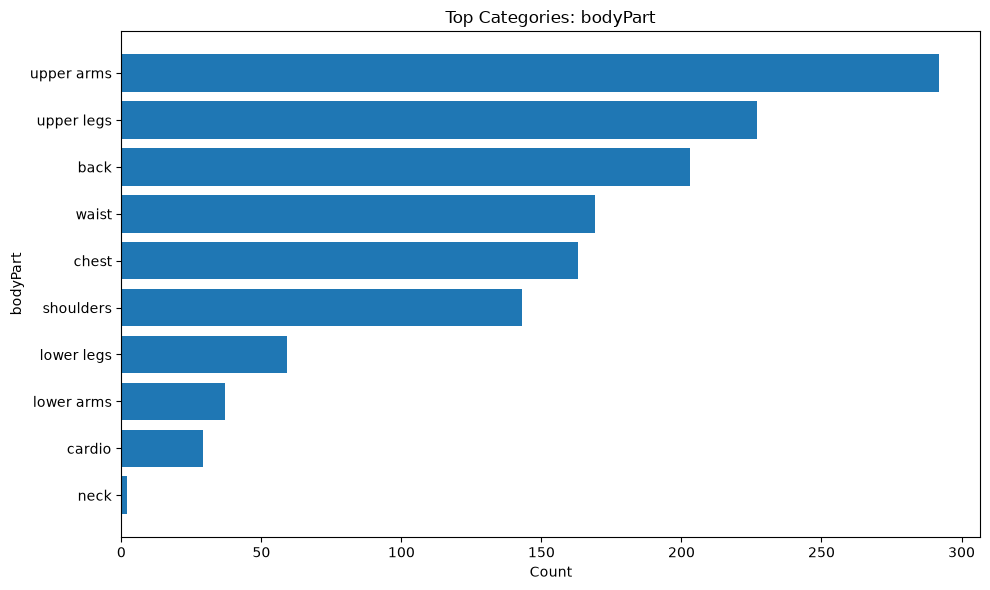

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\top_categories_bodyPart.png


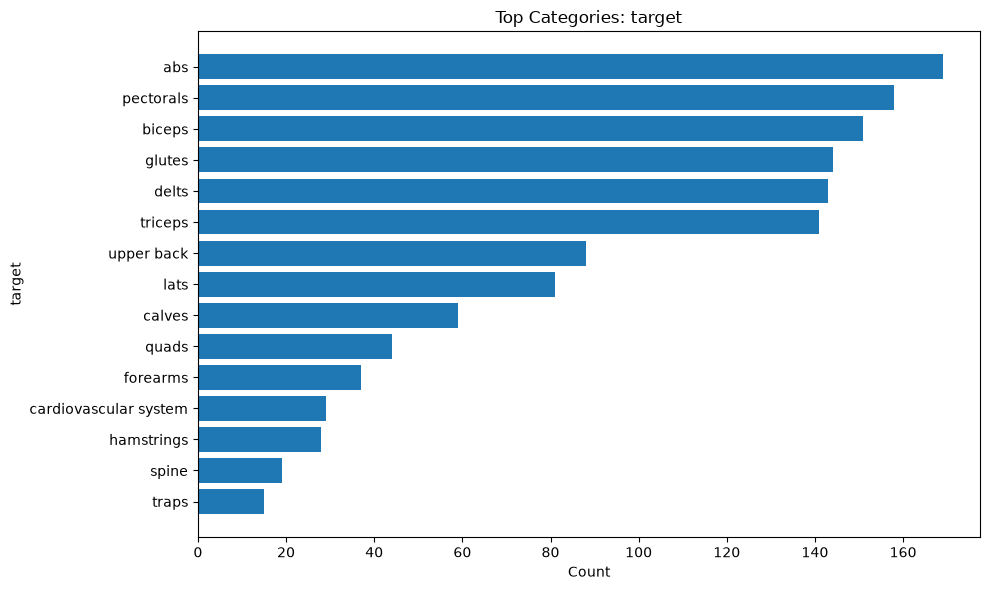

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\top_categories_target.png


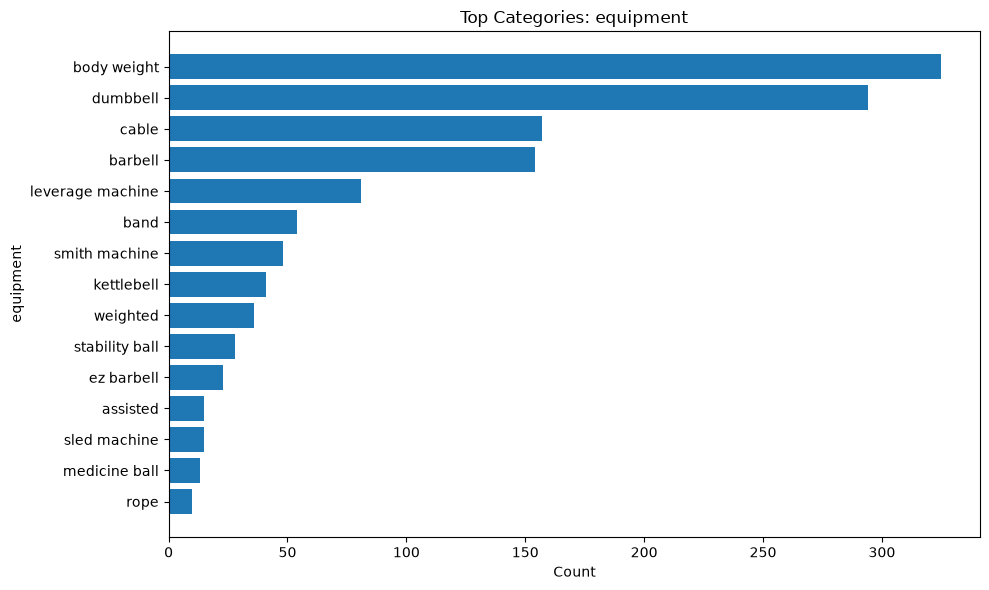

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\top_categories_equipment.png


In [11]:
# Edit these names based on your actual dataset columns.

candidate_category_columns = [
    "bodyPart",
    "body_part",
    "BodyPart",
    "target",
    "Target",
    "targetMuscle",
    "muscle",
    "Muscle",
    "equipment",
    "Equipment"
]

if possible_exercise_dataset_name:
    exercise_df = datasets[possible_exercise_dataset_name]["data"]

    for column in candidate_category_columns:
        if column in exercise_df.columns:
            plot_top_categories(
                exercise_df,
                column=column,
                title=f"Top Categories: {column}",
                filename=f"top_categories_{column}.png"
            )

## Gym Members Dataset Selection

This cell selects the likely gym members dataset and displays its columns and first rows. This dataset is used for charts about workout type, experience, calories, duration, and related metrics.

In [12]:
gym_member_dataset_name = None

for name in datasets.keys():
    lowered = name.lower()
    if "gym" in lowered and ("member" in lowered or "exercise" in lowered):
        gym_member_dataset_name = name
        break

print("Selected possible gym member dataset:", gym_member_dataset_name)

if gym_member_dataset_name:
    gym_df = datasets[gym_member_dataset_name]["data"]
    print(gym_df.columns.tolist())
    display(gym_df.head())

Selected possible gym member dataset: gym_members_exercise_tracking
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Gym Member Category Charts

This cell automatically charts low-cardinality columns related to workout type, experience level, and gender. These help us understand user/workout distributions before ML decisions.

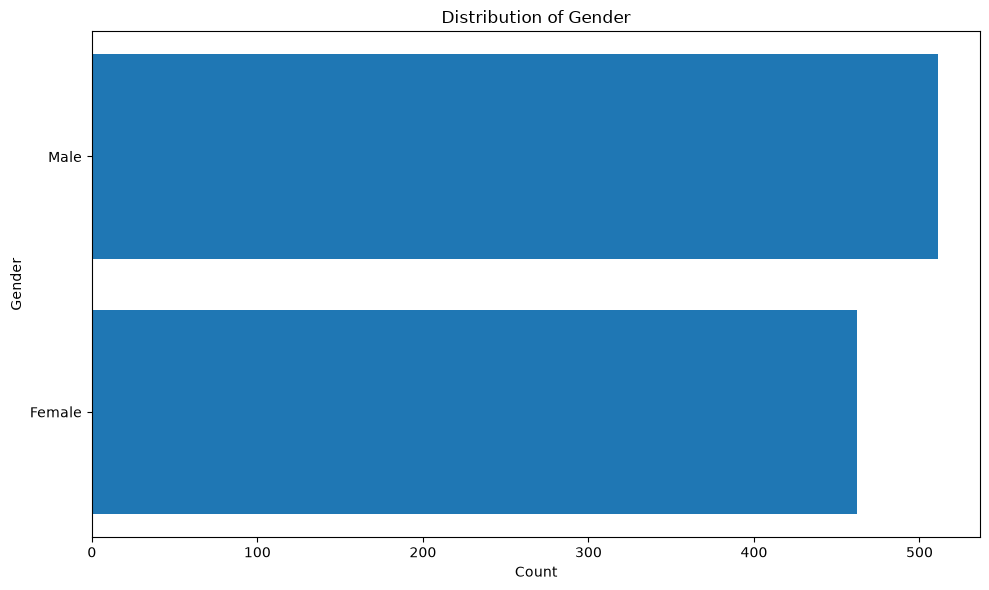

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\distribution_Gender.png


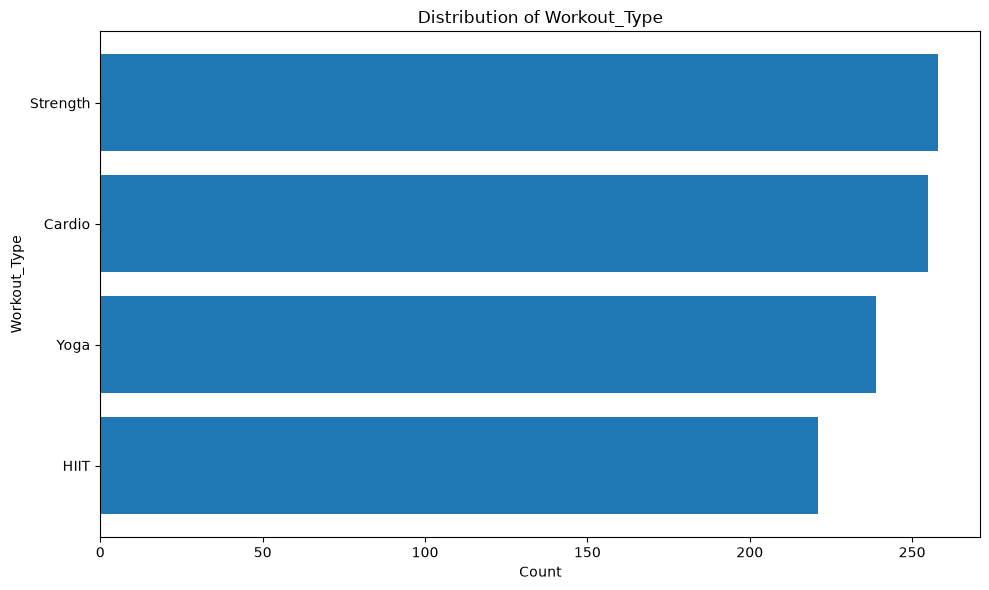

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\distribution_Workout_Type.png


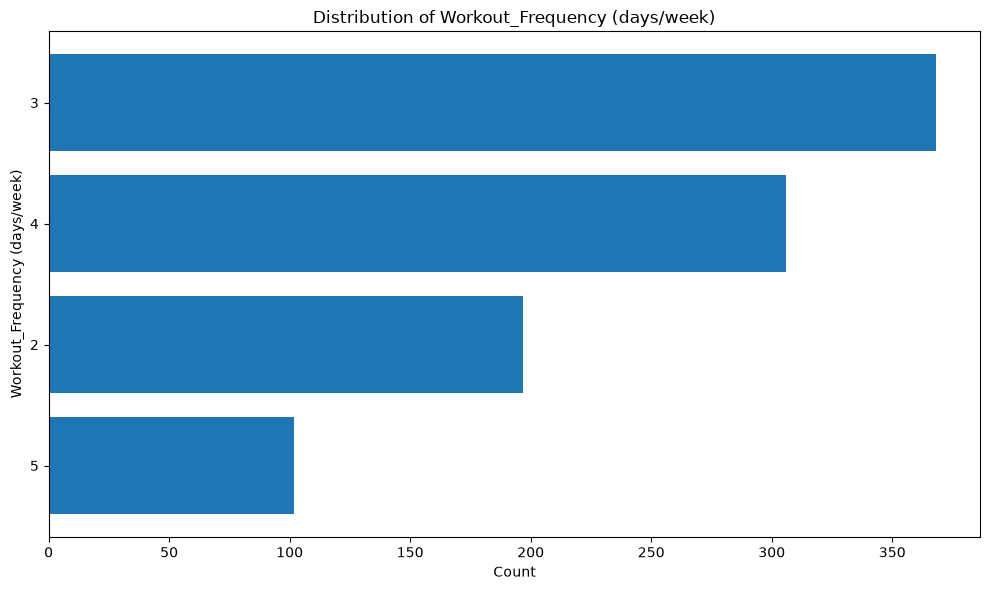

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\distribution_Workout_Frequency__days_week_.png


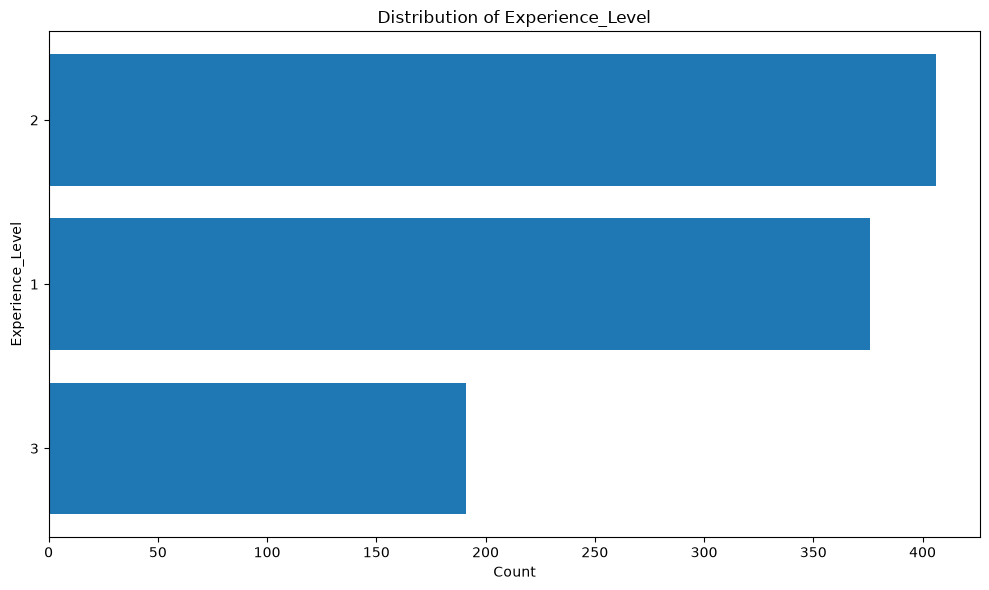

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\distribution_Experience_Level.png


In [13]:
if gym_member_dataset_name:
    gym_df = datasets[gym_member_dataset_name]["data"]

    for column in gym_df.columns:
        normalized = column.lower()

        if any(keyword in normalized for keyword in ["workout", "experience", "gender"]):
            if gym_df[column].nunique() <= 20:
                plot_top_categories(
                    gym_df,
                    column=column,
                    title=f"Distribution of {column}",
                    filename=f"distribution_{column}.png"
                )

## Numeric Distribution Charts

This cell defines and runs histogram charts for numeric gym member fields such as age, weight, height, duration, calories, and heart rate.

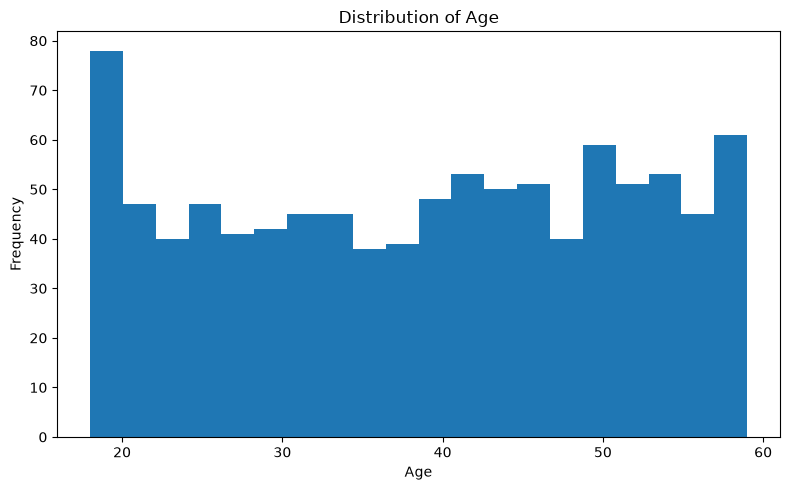

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Age.png


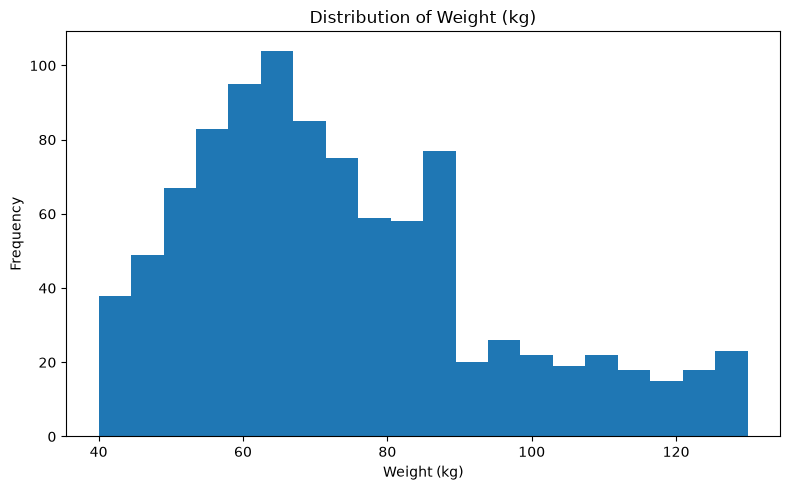

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Weight__kg_.png


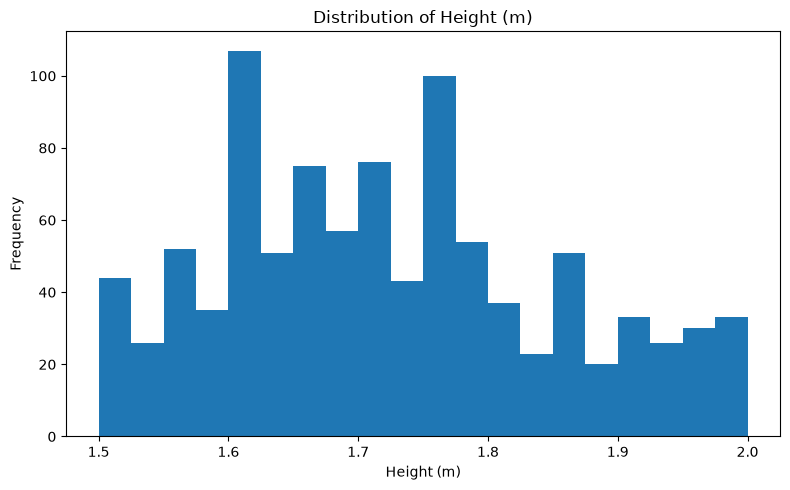

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Height__m_.png


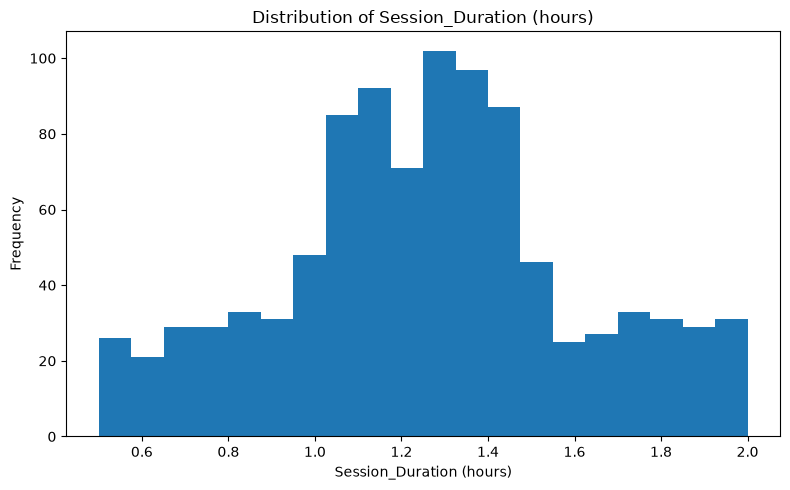

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Session_Duration__hours_.png


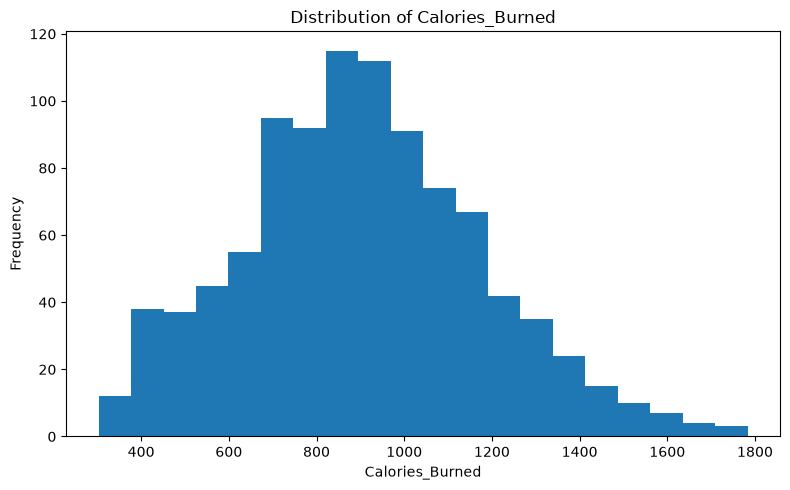

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Calories_Burned.png


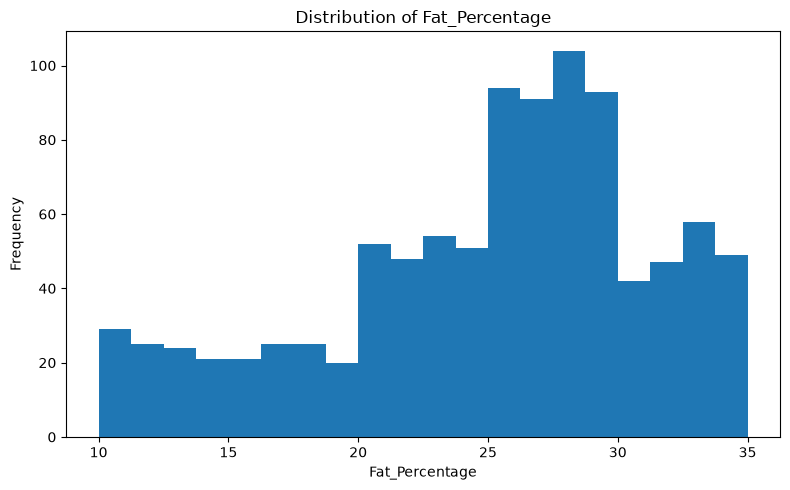

Saved chart: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\hist_Fat_Percentage.png


In [14]:
def plot_numeric_distribution(df: pd.DataFrame, column: str, filename: str):
    """
    Plot histogram for a numeric column.
    """
    if column not in df.columns:
        return

    values = pd.to_numeric(df[column], errors="coerce").dropna()

    if values.empty:
        return

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()

    safe_filename = "".join(
        character if character.isalnum() or character in ["-", "_", "."] else "_"
        for character in filename
    )
    output_path = FIGURES_DIR / safe_filename
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Saved chart:", output_path)


if gym_member_dataset_name:
    gym_df = datasets[gym_member_dataset_name]["data"]

    for column in gym_df.columns:
        normalized = column.lower()

        if any(keyword in normalized for keyword in ["age", "weight", "height", "duration", "calorie", "heart"]):
            plot_numeric_distribution(
                gym_df,
                column=column,
                filename=f"hist_{column}.png"
            )

## Dataset Decision Table

This cell classifies each dataset based on detected exercise or calorie/workout fields. The result helps choose what to clean first for the AuraFitness MVP.

In [15]:
decision_rows = []

for name, item in datasets.items():
    df = item["data"]
    columns_text = " ".join(df.columns.astype(str)).lower()

    has_exercise_fields = any(
        keyword in columns_text
        for keyword in ["exercise", "target", "muscle", "equipment", "instruction"]
    )

    has_calorie_fields = any(
        keyword in columns_text
        for keyword in ["calorie", "duration", "heart", "weight"]
    )

    if has_exercise_fields:
        recommended_use = "Exercise library / recommendation engine"
        mvp_status = "MVP candidate"
    elif has_calorie_fields:
        recommended_use = "EDA / calorie model experiment"
        mvp_status = "Research or later ML"
    else:
        recommended_use = "Needs manual review"
        mvp_status = "Unknown"

    decision_rows.append({
        "dataset_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "recommended_use": recommended_use,
        "mvp_status": mvp_status
    })

decision_df = pd.DataFrame(decision_rows)
decision_df

,dataset_name,rows,columns,recommended_use,mvp_status
0,exercises,1324,23,Exercise library / recommendation engine,MVP candidate
1,gym_members_exercise_tracking,973,15,EDA / calorie model experiment,Research or later ML
2,Gym Exercises Dataset,471,10,Exercise library / recommendation engine,MVP candidate


## Save Dataset Overview Report

This cell saves the overview and decision tables as CSV files in `ai/reports/` so we can review results outside the notebook and use them in the next planning step.

In [16]:
report_path = AI_ROOT / "reports" / "dataset_overview.csv"
decision_path = AI_ROOT / "reports" / "dataset_decision_table.csv"

overview_df.to_csv(report_path, index=False)
decision_df.to_csv(decision_path, index=False)

print("Saved:", report_path)
print("Saved:", decision_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\dataset_overview.csv
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\dataset_decision_table.csv
